In [3]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "No GPU found, running on CPU")

# numpy 2.x ke saath surprise clash karta hai, numpy downgrade karna hoga
!pip install "numpy<2" -q
!pip install scikit-surprise --upgrade -q
!pip install plotly -q
!pip install wordcloud -q

print("All installs done, restarting kernel now...")

# kernel restart karo install ke baad
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

Thu Jun 18 09:10:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

{'status': 'ok', 'restart': True}

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ast
import re
import warnings
import os
import pickle

warnings.filterwarnings('ignore')

# numpy version confirm karo
print(f"NumPy version: {np.__version__}")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import cross_validate, train_test_split as sur_split

print("imported successfully")

try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("CuPy found, GPU will be used for similarity matrix")
except ImportError:
    GPU_AVAILABLE = False
    print("CuPy not available, falling back to CPU")

from wordcloud import WordCloud
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)

print("All imports successful")

NumPy version: 1.26.4
imported successfully
CuPy not available, falling back to CPU
All imports successful


In [3]:
base_path = '/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata'

if os.path.exists(base_path):
    movies_path  = f'{base_path}/tmdb_5000_movies.csv'
    credits_path = f'{base_path}/tmdb_5000_credits.csv'
else:
    movies_path  = 'tmdb_5000_movies.csv'
    credits_path = 'tmdb_5000_credits.csv'

movies_df  = pd.read_csv(movies_path)
credits_df = pd.read_csv(credits_path)

print(f"Movies  : {movies_df.shape}")
print(f"Credits : {credits_df.shape}")
movies_df.head(3)

Movies  : (4803, 20)
Credits : (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""sp...",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, ...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Twentieth Century Fox Film Corporatio...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}, {""iso_3166_1"": ""GB"", ""name"": ""United ...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""name"": ""Action""}]",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug abuse""}, {""id"": 911, ""name"": ""exotic is...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of t...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""Jerry Bruckheimer Films"", ""id"": 130}, {""na...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 80, ""name"": ""Crime""}]",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name"": ""based on novel""}, {""id"": 4289, ""name"": ""secret...",en,Spectre,A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. Whil...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""name"": ""Danjaq"", ""id"": 10761}, {""name"": ""B24"", ""id"": ...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}, {""iso_3166_1"": ""US"", ""name"": ""United States of ...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}, {""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [4]:
print("Column types and null counts")
print(movies_df.info())

missing     = movies_df.isnull().sum()
missing_pct = (missing / len(movies_df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count'  : missing,
    'Percentage (%)' : missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

movies_df[['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']].describe()

Column types and null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   objec

,budget,revenue,runtime,vote_average,vote_count,popularity
count,4.803000e+03,4.803000e+03,4801.000000,4803.000000,4803.000000,4803.000000
mean,2.904504e+07,8.226064e+07,106.875859,6.092172,690.217989,21.492301
std,4.072239e+07,1.628571e+08,22.611935,1.194612,1234.585891,31.816650
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,7.900000e+05,0.000000e+00,94.000000,5.600000,54.000000,4.668070
50%,1.500000e+07,1.917000e+07,103.000000,6.200000,235.000000,12.921594
75%,4.000000e+07,9.291719e+07,118.000000,6.800000,737.000000,28.313505
max,3.800000e+08,2.787965e+09,338.000000,10.000000,13752.000000,875.581305


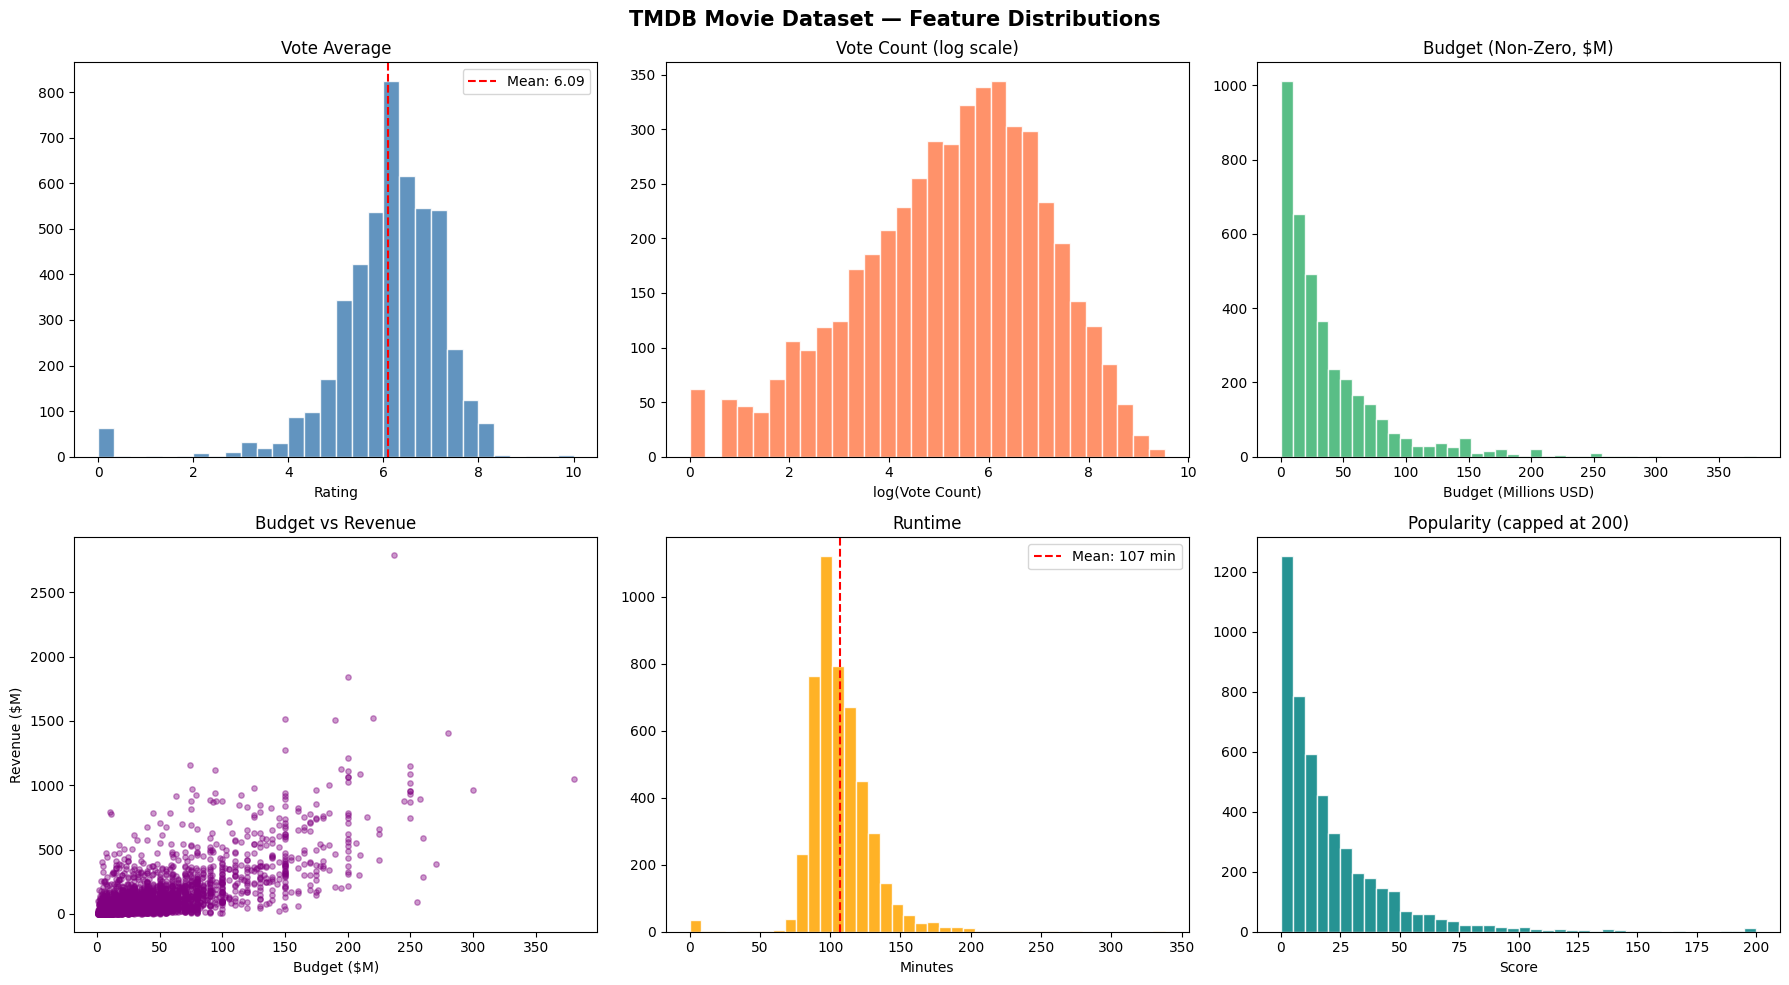

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('TMDB Movie Dataset — Feature Distributions', fontsize=15, fontweight='bold')

axes[0,0].hist(movies_df['vote_average'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Vote Average')
axes[0,0].set_xlabel('Rating')
axes[0,0].axvline(movies_df['vote_average'].mean(), color='red', linestyle='--',
                  label=f"Mean: {movies_df['vote_average'].mean():.2f}")
axes[0,0].legend()

axes[0,1].hist(np.log1p(movies_df['vote_count'].dropna()), bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Vote Count (log scale)')
axes[0,1].set_xlabel('log(Vote Count)')

budget_nonzero = movies_df[movies_df['budget'] > 0]['budget'] / 1e6
axes[0,2].hist(budget_nonzero, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Budget (Non-Zero, $M)')
axes[0,2].set_xlabel('Budget (Millions USD)')

valid = movies_df[(movies_df['budget'] > 1e6) & (movies_df['revenue'] > 1e6)]
axes[1,0].scatter(valid['budget'] / 1e6, valid['revenue'] / 1e6, alpha=0.4, color='purple', s=15)
axes[1,0].set_title('Budget vs Revenue')
axes[1,0].set_xlabel('Budget ($M)')
axes[1,0].set_ylabel('Revenue ($M)')

axes[1,1].hist(movies_df['runtime'].dropna(), bins=40, color='orange', edgecolor='white', alpha=0.85)
axes[1,1].set_title('Runtime')
axes[1,1].set_xlabel('Minutes')
axes[1,1].axvline(movies_df['runtime'].mean(), color='red', linestyle='--',
                  label=f"Mean: {movies_df['runtime'].mean():.0f} min")
axes[1,1].legend()

axes[1,2].hist(movies_df['popularity'].dropna().clip(upper=200), bins=40, color='teal', edgecolor='white', alpha=0.85)
axes[1,2].set_title('Popularity (capped at 200)')
axes[1,2].set_xlabel('Score')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
movies_df['genres_list'] = movies_df['genres'].apply(
    lambda x: [d['name'] for d in ast.literal_eval(x)] if pd.notna(x) and x != '[]' else []
)

genres_exploded = movies_df.explode('genres_list')
genre_counts    = genres_exploded['genres_list'].value_counts().head(20)

fig = px.bar(
    x=genre_counts.values,
    y=genre_counts.index,
    orientation='h',
    color=genre_counts.values,
    color_continuous_scale='Viridis',
    title='Top 20 Movie Genres by Count',
    labels={'x': 'Number of Movies', 'y': 'Genre'},
    height=550
)
fig.update_layout(showlegend=False, yaxis={'categoryorder': 'total ascending'})
fig.show()

genre_rating = (
    genres_exploded
    .groupby('genres_list')['vote_average']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

fig2 = px.bar(
    x=genre_rating.values,
    y=genre_rating.index,
    orientation='h',
    color=genre_rating.values,
    color_continuous_scale='RdYlGn',
    title='Average Rating by Genre',
    labels={'x': 'Avg Rating', 'y': 'Genre'},
    height=480
)
fig2.update_layout(showlegend=False, yaxis={'categoryorder': 'total ascending'})
fig2.show()

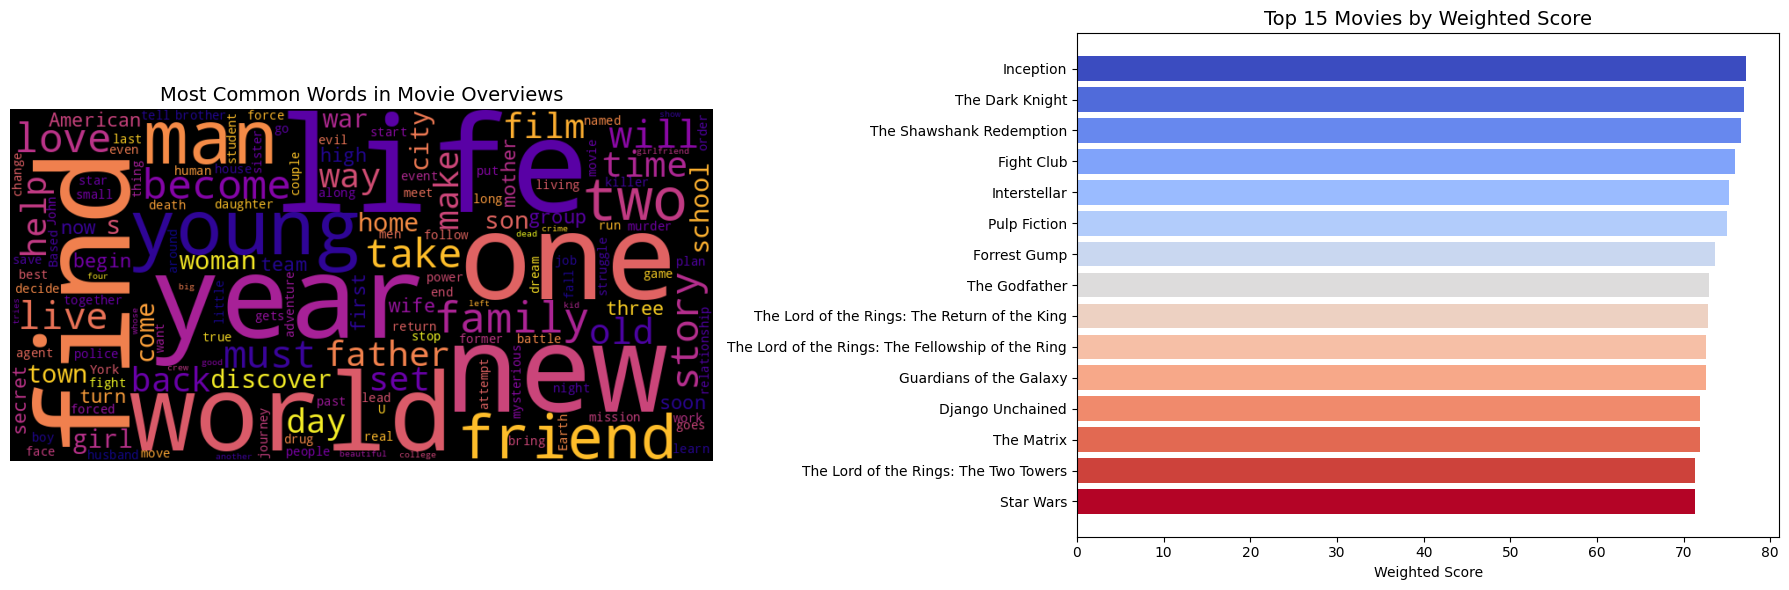

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

all_text = ' '.join(movies_df['overview'].dropna().tolist())

wc = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='plasma',
    max_words=150,
    collocations=False
).generate(all_text)

axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common Words in Movie Overviews', fontsize=14)

movies_df['weighted_score'] = movies_df['vote_average'] * np.log1p(movies_df['vote_count'])
top_movies = movies_df.nlargest(15, 'weighted_score')[['title', 'weighted_score']]

axes[1].barh(top_movies['title'], top_movies['weighted_score'],
             color=plt.cm.coolwarm(np.linspace(0, 1, 15)))
axes[1].set_title('Top 15 Movies by Weighted Score', fontsize=14)
axes[1].set_xlabel('Weighted Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_movies.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
credits_df.columns = ['id', 'title', 'cast', 'crew']
movies_df = movies_df.merge(credits_df[['id', 'cast', 'crew']], on='id', how='left')
print(f"Shape after merge: {movies_df.shape}")


def parse_list_field(x, key='name', limit=None):
    try:
        items = ast.literal_eval(x)
        names = [d[key] for d in items if key in d]
        return names[:limit] if limit else names
    except:
        return []


def get_director(crew_str):
    try:
        crew = ast.literal_eval(crew_str)
        for member in crew:
            if member.get('job') == 'Director':
                return member.get('name', '')
        return ''
    except:
        return ''


def clean_name(name):
    # remove spaces so vectorizer treats full name as one token
    return str(name).replace(' ', '').lower()


movies_df['genres_parsed']   = movies_df['genres'].apply(lambda x: parse_list_field(x))
movies_df['keywords_parsed'] = movies_df['keywords'].apply(lambda x: parse_list_field(x))
movies_df['cast_parsed']     = movies_df['cast'].apply(lambda x: parse_list_field(x, limit=5))
movies_df['director']        = movies_df['crew'].apply(get_director)

movies_df['cast_clean']      = movies_df['cast_parsed'].apply(lambda lst: [clean_name(n) for n in lst])
movies_df['genres_clean']    = movies_df['genres_parsed'].apply(lambda lst: [clean_name(n) for n in lst])
movies_df['keywords_clean']  = movies_df['keywords_parsed'].apply(lambda lst: [clean_name(n) for n in lst])
movies_df['director_clean']  = movies_df['director'].apply(clean_name)
movies_df['overview']        = movies_df['overview'].fillna('')

movies_df[['title', 'director_clean', 'genres_clean', 'cast_clean']].head(3)

Shape after merge: (4803, 24)


,title,director_clean,genres_clean,cast_clean
0,Avatar,jamescameron,"[action, adventure, fantasy, sciencefiction]","[samworthington, zoesaldana, sigourneyweaver, stephenlang, michellerodriguez]"
1,Pirates of the Caribbean: At World's End,goreverbinski,"[adventure, fantasy, action]","[johnnydepp, orlandobloom, keiraknightley, stellanskarsgård, chowyun-fat]"
2,Spectre,sammendes,"[action, adventure, crime]","[danielcraig, christophwaltz, léaseydoux, ralphfiennes, monicabellucci]"


In [9]:
def build_soup(row):
    # director 3x, cast and genres 2x, keywords 1x
    # repeated tokens boost their weight in TF-IDF
    parts = []

    if row['director_clean']:
        parts.extend([row['director_clean']] * 3)

    parts.extend(row['cast_clean'][:5] * 2)
    parts.extend(row['genres_clean'] * 2)
    parts.extend(row['keywords_clean'][:10])

    overview_words = re.sub(r'[^a-zA-Z ]', '', row['overview'].lower()).split()
    parts.extend(overview_words[:50])

    return ' '.join(parts)


movies_df['soup'] = movies_df.apply(build_soup, axis=1)
movies_df = movies_df.reset_index(drop=True)
movies_df['index'] = movies_df.index

print(f"Soup built for {len(movies_df)} movies")
print("\nSample soup (Dark Knight):")
dk = movies_df[movies_df['title'].str.contains('Dark Knight', na=False)]
if len(dk):
    print(dk['soup'].values[0][:400])

Soup built for 4803 movies

Sample soup (Dark Knight):
christophernolan christophernolan christophernolan christianbale michaelcaine garyoldman annehathaway tomhardy christianbale michaelcaine garyoldman annehathaway tomhardy action crime drama thriller action crime drama thriller dccomics crimefighter terrorist secretidentity burglar hostagedrama timebomb gothamcity vigilante cover-up following the death of district attorney harvey dent batman assume


In [10]:
print("Building TF-IDF matrix...")

tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_features=15000,
    sublinear_tf=True
)

tfidf_matrix = tfidf.fit_transform(movies_df['soup'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

if GPU_AVAILABLE:
    from cupyx.scipy.sparse import csr_matrix as gpu_csr
    print("Computing cosine similarity on GPU...")
    tfidf_gpu  = gpu_csr(tfidf_matrix)
    cosine_sim = cp.asnumpy(cp.dot(tfidf_gpu, tfidf_gpu.T).toarray())
else:
    print("Computing cosine similarity on CPU...")
    cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Similarity matrix shape : {cosine_sim.shape}")
print(f"Memory usage            : {cosine_sim.nbytes / 1e6:.1f} MB")

title_to_idx = pd.Series(movies_df.index, index=movies_df['title']).drop_duplicates()
print(f"Index built for {len(title_to_idx)} titles")

Building TF-IDF matrix...
TF-IDF matrix shape: (4803, 15000)
Computing cosine similarity on CPU...
Similarity matrix shape : (4803, 4803)
Memory usage            : 184.6 MB
Index built for 4803 titles


In [11]:
def recommend_movies(title, n=10):
    if title not in title_to_idx:
        matches = movies_df[movies_df['title'].str.contains(title, case=False, na=False)]
        if len(matches) == 0:
            print(f"No match found for '{title}'")
            return None
        title = matches.iloc[0]['title']
        print(f"Using closest match: '{title}'")

    idx        = title_to_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n+1]

    movie_indices     = [i[0] for i in sim_scores]
    similarity_values = [round(i[1], 4) for i in sim_scores]

    result = movies_df.iloc[movie_indices][[
        'title', 'vote_average', 'vote_count',
        'popularity', 'genres_parsed', 'director', 'release_date'
    ]].copy()

    result['similarity_score'] = similarity_values
    result['genres']           = result['genres_parsed'].apply(lambda x: ', '.join(x[:3]))
    result = result.drop(columns=['genres_parsed']).reset_index(drop=True)
    result.index += 1
    return result


def display_recommendations(title, n=10):
    print(f"\n{'='*60}")
    print(f"  Top {n} recommendations for: {title}")
    print(f"{'='*60}")
    recs = recommend_movies(title, n=n)
    if recs is not None:
        display(
            recs[['title', 'similarity_score', 'vote_average', 'genres', 'director']]
            .style
            .background_gradient(subset=['similarity_score'], cmap='YlOrRd')
            .background_gradient(subset=['vote_average'], cmap='Greens')
            .format({'similarity_score': '{:.4f}', 'vote_average': '{:.1f}'})
        )
    return recs

In [12]:
recs_dk        = display_recommendations("The Dark Knight", n=10)
recs_avengers  = display_recommendations("The Avengers", n=10)
recs_inception = display_recommendations("Inception", n=10)
recs_godfather = display_recommendations("The Godfather", n=10)


  Top 10 recommendations for: The Dark Knight


,title,similarity_score,vote_average,genres,director
1,The Dark Knight Rises,0.4788,7.6,"Action, Crime, Drama",Christopher Nolan
2,Batman Begins,0.4121,7.5,"Action, Crime, Drama",Christopher Nolan
3,The Prestige,0.2390,8.0,"Drama, Mystery, Thriller",Christopher Nolan
4,Batman Forever,0.2023,5.2,"Action, Crime, Fantasy",Joel Schumacher
5,Amidst the Devil's Wings,0.1955,0.0,"Drama, Action, Crime",
6,Batman Returns,0.1756,6.6,"Action, Fantasy",Tim Burton
7,Interstellar,0.1733,8.1,"Adventure, Drama, Science Fiction",Christopher Nolan
8,Insomnia,0.1574,6.8,"Crime, Mystery, Thriller",Christopher Nolan
9,Exiled,0.1463,7.0,"Action, Crime, Thriller",Johnnie To
10,London Has Fallen,0.1399,5.8,"Action, Crime, Thriller",Babak Najafi



  Top 10 recommendations for: The Avengers


,title,similarity_score,vote_average,genres,director
1,Avengers: Age of Ultron,0.5720,7.3,"Action, Adventure, Science Fiction",Joss Whedon
2,Captain America: The Winter Soldier,0.3254,7.6,"Action, Adventure, Science Fiction",Anthony Russo
3,Captain America: Civil War,0.2512,7.1,"Adventure, Action, Science Fiction",Anthony Russo
4,Serenity,0.2217,7.4,"Science Fiction, Action, Adventure",Joss Whedon
5,Thor: The Dark World,0.1917,6.8,"Action, Adventure, Fantasy",Alan Taylor
6,Captain America: The First Avenger,0.1891,6.6,"Action, Adventure, Science Fiction",Joe Johnston
7,Iron Man 2,0.1885,6.6,"Adventure, Action, Science Fiction",Jon Favreau
8,Ant-Man,0.1835,7.0,"Science Fiction, Action, Adventure",Peyton Reed
9,Iron Man 3,0.1800,6.8,"Action, Adventure, Science Fiction",Shane Black
10,The Incredible Hulk,0.1755,6.1,"Science Fiction, Action, Adventure",Louis Leterrier



  Top 10 recommendations for: Inception


,title,similarity_score,vote_average,genres,director
1,Don Jon,0.2102,5.9,"Romance, Comedy, Drama",Joseph Gordon-Levitt
2,G.I. Joe: The Rise of Cobra,0.1976,5.6,"Adventure, Action, Thriller",Stephen Sommers
3,Premium Rush,0.1938,6.2,"Crime, Action, Thriller",David Koepp
4,Looper,0.1906,6.6,"Action, Thriller, Science Fiction",Rian Johnson
5,Hesher,0.1725,6.7,Drama,Spencer Susser
6,Cypher,0.1725,6.7,"Thriller, Science Fiction, Mystery",Vincenzo Natali
7,The Dark Knight Rises,0.1631,7.6,"Action, Crime, Drama",Christopher Nolan
8,Insomnia,0.1598,6.8,"Crime, Mystery, Thriller",Christopher Nolan
9,The Prestige,0.1591,8.0,"Drama, Mystery, Thriller",Christopher Nolan
10,The Walk,0.1553,6.9,"Adventure, Drama, Thriller",Robert Zemeckis



  Top 10 recommendations for: The Godfather


,title,similarity_score,vote_average,genres,director
1,The Godfather: Part II,0.4024,8.3,"Drama, Crime",Francis Ford Coppola
2,The Godfather: Part III,0.2813,7.1,"Crime, Drama, Thriller",Francis Ford Coppola
3,The Cotton Club,0.2097,6.6,"Music, Drama, Crime",Francis Ford Coppola
4,Apocalypse Now,0.2054,8.0,"Drama, War",Francis Ford Coppola
5,The Rainmaker,0.1796,6.7,"Drama, Crime, Thriller",Francis Ford Coppola
6,The Outsiders,0.1698,6.9,"Crime, Drama",Francis Ford Coppola
7,New York Stories,0.1473,6.2,"Comedy, Drama, Romance",Francis Ford Coppola
8,Peggy Sue Got Married,0.1457,5.9,"Comedy, Drama, Fantasy",Francis Ford Coppola
9,The Conversation,0.1376,7.5,"Crime, Drama, Mystery",Francis Ford Coppola
10,Twixt,0.1298,5.0,"Horror, Thriller",Francis Ford Coppola


In [13]:
# using TMDB vote data to generate synthetic ratings
# no external dataset needed

ratings_source = movies_df[['id', 'vote_average', 'vote_count']].copy()
ratings_source.columns = ['movieId', 'rating', 'vote_count']
ratings_source['rating'] = ratings_source['rating'] / 2  # scale 0-10 to 0-5

np.random.seed(42)
rows = []

for _, row in ratings_source.iterrows():
    n_raters = min(int(row['vote_count'] / 100), 50)
    if n_raters < 1:
        continue
    user_ids = np.random.choice(range(1, 501), size=n_raters, replace=False)
    for uid in user_ids:
        noise = np.random.normal(0, 0.3)
        r     = float(np.clip(row['rating'] + noise, 0.5, 5.0))
        rows.append({
            'userId'  : uid,
            'movieId' : row['movieId'],
            'rating'  : round(r * 2) / 2
        })

ratings_df = pd.DataFrame(rows).drop_duplicates(subset=['userId', 'movieId'])

print(f"Users   : {ratings_df['userId'].nunique()}")
print(f"Movies  : {ratings_df['movieId'].nunique()}")
print(f"Ratings : {len(ratings_df):,}")
print(f"Avg     : {ratings_df['rating'].mean():.2f}")
sparsity = 1 - len(ratings_df) / (ratings_df['userId'].nunique() * ratings_df['movieId'].nunique())
print(f"Sparsity: {sparsity:.2%}")
ratings_df.head()

Users   : 500
Movies  : 3162
Ratings : 29,377
Avg     : 3.38
Sparsity: 98.14%


,userId,movieId,rating
0,362,19995.0,3.5
1,74,19995.0,4.0
2,375,19995.0,4.0
3,156,19995.0,3.5
4,105,19995.0,4.0


In [14]:
reader = Reader(rating_scale=(0.5, 5.0))
data   = Dataset.load_from_df(ratings_df[['userId', 'movieId', 'rating']], reader)

svd_model = SVD(n_factors=150, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42)

print("Running 5-fold cross-validation...")
cv_results = cross_validate(svd_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print(f"\nMean RMSE : {cv_results['test_rmse'].mean():.4f}  (+/- {cv_results['test_rmse'].std():.4f})")
print(f"Mean MAE  : {cv_results['test_mae'].mean():.4f}  (+/- {cv_results['test_mae'].std():.4f})")

trainset, testset = sur_split(data, test_size=0.2, random_state=42)
svd_model.fit(trainset)
predictions = svd_model.test(testset)

print("\nFinal test set results:")
accuracy.rmse(predictions)
accuracy.mae(predictions)

Running 5-fold cross-validation...
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.4002  0.3990  0.4011  0.4027  0.3980  0.4002  0.0016  
MAE (testset)     0.3175  0.3135  0.3190  0.3184  0.3142  0.3165  0.0023  
Fit time          0.38    0.39    0.38    0.39    0.38    0.38    0.00    
Test time         0.03    0.03    0.03    0.03    0.03    0.03    0.00    

Mean RMSE : 0.4002  (+/- 0.0016)
Mean MAE  : 0.3165  (+/- 0.0023)

Final test set results:
RMSE: 0.4055
MAE:  0.3202


0.3201863610102223

In [15]:
def get_cf_recommendations(user_id, n=10):
    rated_movies = set(ratings_df[ratings_df['userId'] == user_id]['movieId'].tolist())
    all_movies   = ratings_df['movieId'].unique()
    unrated      = [m for m in all_movies if m not in rated_movies]

    preds = [(movie_id, svd_model.predict(user_id, movie_id).est) for movie_id in unrated]
    preds.sort(key=lambda x: x[1], reverse=True)

    result = pd.DataFrame(preds[:n], columns=['movieId', 'predicted_rating'])
    result.index = range(1, n + 1)
    return result


print("CF recommendations for user 42:")
display(get_cf_recommendations(user_id=42, n=10))

CF recommendations for user 42:


,movieId,predicted_rating
1,238.0,4.226203
2,680.0,4.211260
3,240.0,4.209818
4,278.0,4.203378
5,207.0,4.198923
6,274.0,4.181645
7,13.0,4.173311
8,77.0,4.168050
9,424.0,4.158626
10,429.0,4.154497


In [16]:
def hybrid_recommend(title, user_id=None, n=10, alpha=0.6):
    print(f"\n{'='*60}")
    print(f"  Hybrid recommendations for: {title}")
    if user_id:
        print(f"  User: {user_id}  |  alpha={alpha} (content) / {1-alpha:.1f} (CF)")
    print(f"{'='*60}")

    content_recs = recommend_movies(title, n=n * 3)
    if content_recs is None:
        return None

    if user_id is None:
        display(content_recs[['title', 'similarity_score', 'vote_average', 'genres', 'director']].head(n))
        return content_recs.head(n)

    content_recs['content_score'] = MinMaxScaler().fit_transform(content_recs[['similarity_score']])

    def get_cf_score(movie_title):
        row = movies_df[movies_df['title'] == movie_title]
        if len(row) == 0:
            return 0.5
        return svd_model.predict(user_id, row['id'].values[0]).est / 5.0

    content_recs['cf_score']     = content_recs['title'].apply(get_cf_score)
    content_recs['hybrid_score'] = alpha * content_recs['content_score'] + (1 - alpha) * content_recs['cf_score']

    result = content_recs.nlargest(n, 'hybrid_score').reset_index(drop=True)
    result.index += 1

    display(
        result[['title', 'hybrid_score', 'content_score', 'cf_score', 'vote_average', 'genres']]
        .style
        .background_gradient(subset=['hybrid_score'], cmap='YlOrRd')
        .format({'hybrid_score': '{:.4f}', 'content_score': '{:.4f}',
                 'cf_score': '{:.4f}', 'vote_average': '{:.1f}'})
    )
    return result


hybrid_recommend("The Dark Knight", user_id=42, n=10)
hybrid_recommend("Inception", user_id=7, n=10)


  Hybrid recommendations for: The Dark Knight
  User: 42  |  alpha=0.6 (content) / 0.4 (CF)


,title,hybrid_score,content_score,cf_score,vote_average,genres
1,The Dark Knight Rises,0.9145,1.0000,0.7861,7.6,"Action, Crime, Drama"
2,Batman Begins,0.8108,0.8290,0.7837,7.5,"Action, Crime, Drama"
3,The Prestige,0.5508,0.3851,0.7994,8.0,"Drama, Mystery, Thriller"
4,Interstellar,0.4428,0.2167,0.7821,8.1,"Adventure, Drama, Science Fiction"
5,Batman Forever,0.4328,0.2910,0.6455,5.2,"Action, Crime, Fantasy"
6,Amidst the Devil's Wings,0.4309,0.2736,0.6668,0.0,"Drama, Action, Crime"
7,Memento,0.4114,0.1300,0.8336,8.1,"Mystery, Thriller"
8,Batman Returns,0.3903,0.2226,0.6419,6.6,"Action, Fantasy"
9,Inception,0.3900,0.1110,0.8085,8.1,"Action, Thriller, Science Fiction"
10,Insomnia,0.3648,0.1759,0.6482,6.8,"Crime, Mystery, Thriller"



  Hybrid recommendations for: Inception
  User: 7  |  alpha=0.6 (content) / 0.4 (CF)


,title,hybrid_score,content_score,cf_score,vote_average,genres
1,Don Jon,0.8480,1.0000,0.6200,5.9,"Romance, Comedy, Drama"
2,G.I. Joe: The Rise of Cobra,0.7540,0.8835,0.5596,5.6,"Adventure, Action, Thriller"
3,Premium Rush,0.7478,0.8484,0.5970,6.2,"Crime, Action, Thriller"
4,Looper,0.7461,0.8189,0.6370,6.6,"Action, Thriller, Science Fiction"
5,Cypher,0.6474,0.6516,0.6411,6.7,"Thriller, Science Fiction, Mystery"
6,Hesher,0.6405,0.6516,0.6239,6.7,Drama
7,The Dark Knight Rises,0.6345,0.5647,0.7392,7.6,"Action, Crime, Drama"
8,The Prestige,0.6312,0.5277,0.7864,8.0,"Drama, Mystery, Thriller"
9,Memento,0.5909,0.4603,0.7868,8.1,"Mystery, Thriller"
10,Insomnia,0.5837,0.5342,0.6579,6.8,"Crime, Mystery, Thriller"


,title,vote_average,vote_count,popularity,director,release_date,similarity_score,genres,content_score,cf_score,hybrid_score
1,Don Jon,5.9,1671,33.296684,Joseph Gordon-Levitt,2013-07-26,0.2102,"Romance, Comedy, Drama",1.000000,0.620003,0.848001
2,G.I. Joe: The Rise of Cobra,5.6,1962,32.852443,Stephen Sommers,2009-08-04,0.1976,"Adventure, Action, Thriller",0.883549,0.559570,0.753958
3,Premium Rush,6.2,832,17.709888,David Koepp,2012-08-24,0.1938,"Crime, Action, Thriller",0.848429,0.596979,0.747849
4,Looper,6.6,4697,46.377628,Rian Johnson,2012-09-26,0.1906,"Action, Thriller, Science Fiction",0.818854,0.637026,0.746123
5,Cypher,6.7,192,11.636883,Vincenzo Natali,2002-10-01,0.1725,"Thriller, Science Fiction, Mystery",0.651571,0.641087,0.647377
6,Hesher,6.7,212,13.635828,Spencer Susser,2010-01-22,0.1725,Drama,0.651571,0.623912,0.640507
7,The Dark Knight Rises,7.6,9106,112.312950,Christopher Nolan,2012-07-16,0.1631,"Action, Crime, Drama",0.564695,0.739182,0.634490
8,The Prestige,8.0,4391,74.440708,Christopher Nolan,2006-10-19,0.1591,"Drama, Mystery, Thriller",0.527726,0.786368,0.631183
9,Memento,8.1,4028,60.715151,Christopher Nolan,2000-10-11,0.1518,"Mystery, Thriller",0.460259,0.786769,0.590863
10,Insomnia,6.8,1148,41.322708,Christopher Nolan,2002-05-24,0.1598,"Crime, Mystery, Thriller",0.534196,0.657883,0.583671


SVD Evaluation Metrics
───────────────────────────────────
  RMSE         : 0.4055
  MAE          : 0.3202
  Precision@5  : 0.8468
  Precision@10 : 0.6518


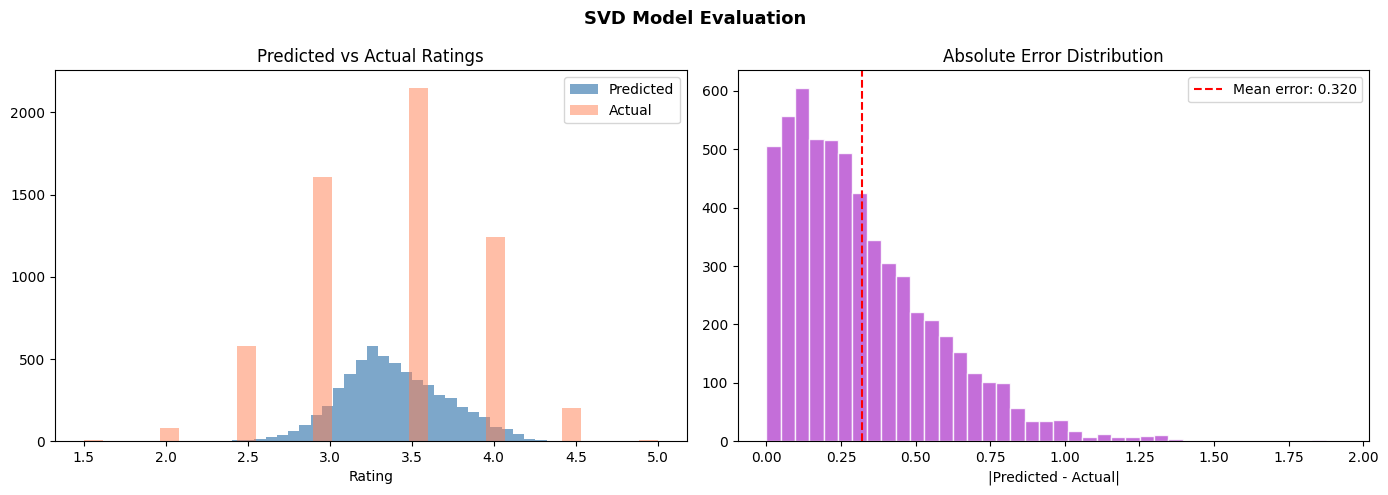

In [17]:
def precision_at_k(predictions, k=10, threshold=3.5):
    user_ratings = {}
    for pred in predictions:
        user_ratings.setdefault(pred.uid, []).append((pred.est, pred.r_ui))

    precisions = []
    for uid, ratings in user_ratings.items():
        ratings.sort(key=lambda x: x[0], reverse=True)
        top_k      = ratings[:k]
        n_relevant = sum(true_r >= threshold for _, true_r in top_k)
        precisions.append(n_relevant / k)

    return np.mean(precisions)


rmse_val = accuracy.rmse(predictions, verbose=False)
mae_val  = accuracy.mae(predictions, verbose=False)
p5       = precision_at_k(predictions, k=5)
p10      = precision_at_k(predictions, k=10)

print("SVD Evaluation Metrics")
print(f"{'─'*35}")
print(f"  RMSE         : {rmse_val:.4f}")
print(f"  MAE          : {mae_val:.4f}")
print(f"  Precision@5  : {p5:.4f}")
print(f"  Precision@10 : {p10:.4f}")

pred_ratings = [p.est  for p in predictions]
true_ratings = [p.r_ui for p in predictions]
errors       = [abs(p.est - p.r_ui) for p in predictions]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pred_ratings, bins=30, alpha=0.7, label='Predicted', color='steelblue')
axes[0].hist(true_ratings, bins=30, alpha=0.5, label='Actual', color='coral')
axes[0].set_title('Predicted vs Actual Ratings')
axes[0].set_xlabel('Rating')
axes[0].legend()

axes[1].hist(errors, bins=40, color='mediumorchid', edgecolor='white', alpha=0.85)
axes[1].set_title('Absolute Error Distribution')
axes[1].set_xlabel('|Predicted - Actual|')
axes[1].axvline(np.mean(errors), color='red', linestyle='--',
                label=f'Mean error: {np.mean(errors):.3f}')
axes[1].legend()

plt.suptitle('SVD Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
flask_code = '''
from flask import Flask, request, jsonify
import pickle, pandas as pd, numpy as np

app = Flask(__name__)

cosine_sim   = pickle.load(open("cosine_sim.pkl", "rb"))
movies_df    = pickle.load(open("movies_df.pkl", "rb"))
title_to_idx = pd.Series(movies_df.index, index=movies_df["title"]).drop_duplicates()


@app.route("/recommend", methods=["GET"])
def recommend():
    title = request.args.get("title", "")
    n     = int(request.args.get("n", 10))

    if not title:
        return jsonify({"error": "Provide a title via ?title="}), 400

    if title not in title_to_idx:
        matches = movies_df[movies_df["title"].str.contains(title, case=False, na=False)]
        if len(matches) == 0:
            return jsonify({"error": f"Movie not found: {title}"}), 404
        title = matches.iloc[0]["title"]

    idx        = title_to_idx[title]
    sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:n+1]
    indices    = [i[0] for i in sim_scores]

    result           = movies_df.iloc[indices][["title", "vote_average", "genres_parsed", "director"]].copy()
    result["similarity"] = [round(s[1], 4) for s in sim_scores]
    result["genres"] = result["genres_parsed"].apply(lambda x: ", ".join(x[:3]))
    result           = result.drop(columns=["genres_parsed"])

    return jsonify({
        "query"           : title,
        "recommendations" : result.to_dict(orient="records")
    })


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "movies_loaded": len(movies_df)})


if __name__ == "__main__":
    app.run(debug=True, port=5000)
'''

with open('app.py', 'w') as f:
    f.write(flask_code)

print("Flask app saved as app.py")
print("To run : python app.py")
print("Test   : curl 'http://localhost:5000/recommend?title=Inception&n=5'")

Flask app saved as app.py
To run : python app.py
Test   : curl 'http://localhost:5000/recommend?title=Inception&n=5'


In [19]:
with open('cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)

save_cols = [
    'id', 'title', 'overview', 'genres_parsed', 'director',
    'vote_average', 'vote_count', 'popularity', 'release_date',
    'soup', 'weighted_score'
]
movies_df[save_cols].to_pickle('movies_df.pkl')

with open('svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)

print("cosine_sim.pkl  saved")
print("movies_df.pkl   saved")
print("svd_model.pkl   saved")

cosine_sim.pkl  saved
movies_df.pkl   saved
svd_model.pkl   saved
